In [1]:
from datasets import load_dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


dataset = load_dataset("bitext/Bitext-retail-banking-llm-chatbot-training-dataset")
print(dataset["train"][0])
df = dataset["train"].to_pandas()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

bitext-retail-banking-llm-chatbot-traini(…):   0%|          | 0.00/7.87M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25545 [00:00<?, ? examples/s]

{'tags': 'BCIPZ', 'instruction': 'I would like to acivate a card, can you help me?', 'category': 'CARD', 'intent': 'activate_card', 'response': 'I\'m here to assist you with that! Activating your card is an important step to starting and enjoying its benefits. Here\'s how you can activate your card:\n\n1. Locate the activation instructions: Depending on the card issuer, you may find the activation instructions on a sticker attached to the card itself, in the welcome package, or on the issuer\'s website.\n\n2. Visit the card issuer\'s activation website: Using your computer or mobile device, open a web browser and navigate to the card issuer\'s website. Look for the activation page or section.\n\n3. Enter the required information: Follow the prompts on the activation page and provide the necessary information. This may include your card number, personal details, and security code.\n\n4. Set up your card: Once you\'ve entered the required information, you may have the option to set up a 

# Chatbot analysis
## Background
I would like to practice some intent recognition on a chatbot.
I will work here with the Bitext-retail-banking-llm-chatbot-training-dataset available through [HuggingFace](https://huggingface.co/datasets/bitext/Bitext-retail-banking-llm-chatbot-training-dataset?utm_source=chatgpt.com).

Unless already done, you must first install huggingface_hub and dataset
> conda install -c huggingface datasets huggingface_hub

> conda install -c huggingface datasets


## EDA
Let's first have a look at the dataset.

In [2]:
df.head()

,tags,instruction,category,intent,response
0,BCIPZ,"I would like to acivate a card, can you help me?",CARD,activate_card,I'm here to assist you with that! Activating y...
1,BCILZ,"I have to activate an Visa online, how can I d...",CARD,activate_card,I'm here to assist you with activating your {{...
2,BCIPQZ,I'd like to actiate a card where do i do it,CARD,activate_card,I can help you with that! Activating your card...
3,BCLPQZ,I'd likke to activate a visa on mobile i need ...,CARD,activate_card,I'm here to assist you with activating your {{...
4,BCILPZ,"I would ilke to activate a credit card online,...",CARD,activate_card,I'm here to assist you with activating your cr...


In [3]:
df.info()
df.describe(include="all")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25545 entries, 0 to 25544
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   tags         25545 non-null  object
 1   instruction  25545 non-null  object
 2   category     25545 non-null  object
 3   intent       25545 non-null  object
 4   response     25545 non-null  object
dtypes: object(5)
memory usage: 998.0+ KB


,tags,instruction,category,intent,response
count,25545,25545,25545,25545,25545
unique,370,25545,9,26,25545
top,BCIPZ,"I got to set up a apssword, could you help me?",CARD,activate_card,I'd be happy to assist you in setting up a pas...
freq,818,1,5980,1000,1


What intents are there? How many different ones? Amd how many each per category?

In [4]:
print("Number of intents:", df["intent"].nunique())
df["intent"].value_counts()

Number of intents: 26


,count
intent,
activate_card,1000
find_branch,1000
check_recent_transactions,999
human_agent,999
close_account,999
customer_service,998
find_ATM,998
block_card,998
activate_card_international_usage,997


The intents are distributed very evenly.
There are deviations mainly in intents related to passwords (set_up_password, get_password) and to a lesser extent in check_fees.

Next, the text length should be examined and checked for duplicates.

In [5]:
df["text_length"] = df["instruction"].apply(lambda x: len(x.split()))

df["text_length"].describe()

,text_length
count,25545.000000
mean,11.129967
std,2.734339
min,2.000000
25%,9.000000
50%,11.000000
75%,13.000000
max,23.000000


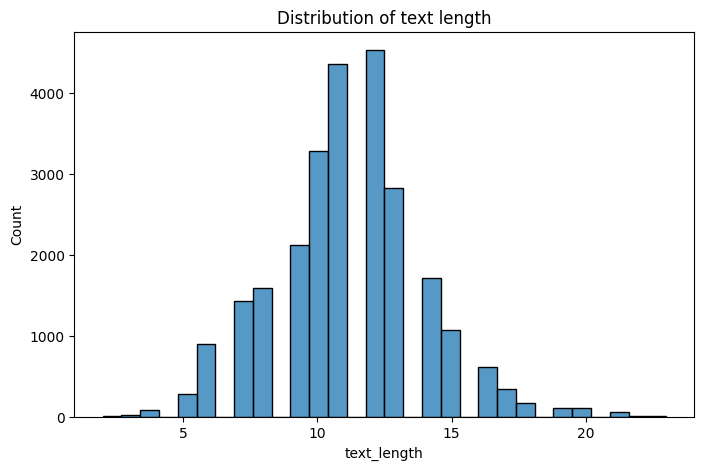

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(df["text_length"], bins=30)
plt.title("Distribution of text length")
plt.show()

In [7]:
df.duplicated(subset=["instruction"]).sum()

np.int64(0)

No duplicates, so no need to consider how to deal with them.
Next, what are the most frequent words?
For this, I also used
> conda install -c conda-forge wordcloud

I personally don't think a word cloud gives you too many insights but it's a nice visualization to get a very rough idea of the most frequent words.

In [8]:
from collections import Counter
import re

all_words = " ".join(df["instruction"]).lower()
all_words = re.sub(r"[^\w\s]", "", all_words)

word_counts = Counter(all_words.split())

print(word_counts.most_common(20))

[('i', 27652), ('to', 20150), ('a', 12948), ('it', 10722), ('do', 9122), ('help', 8709), ('me', 7444), ('can', 5639), ('could', 5584), ('need', 5378), ('the', 5352), ('my', 5260), ('like', 5054), ('how', 4560), ('card', 4304), ('for', 4264), ('id', 3838), ('an', 3830), ('where', 3788), ('fucking', 3515)]


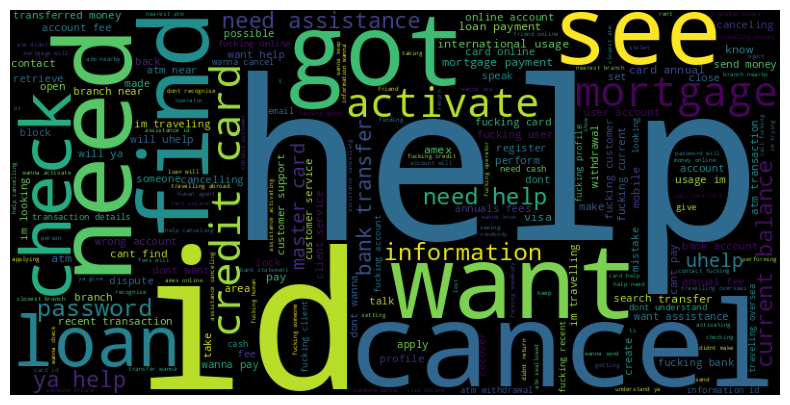

In [9]:
!pip install wordcloud
from wordcloud import WordCloud

wc = WordCloud(width=800, height=400).generate(all_words)

plt.figure(figsize=(10,5))
plt.imshow(wc)
plt.axis("off")
plt.show()

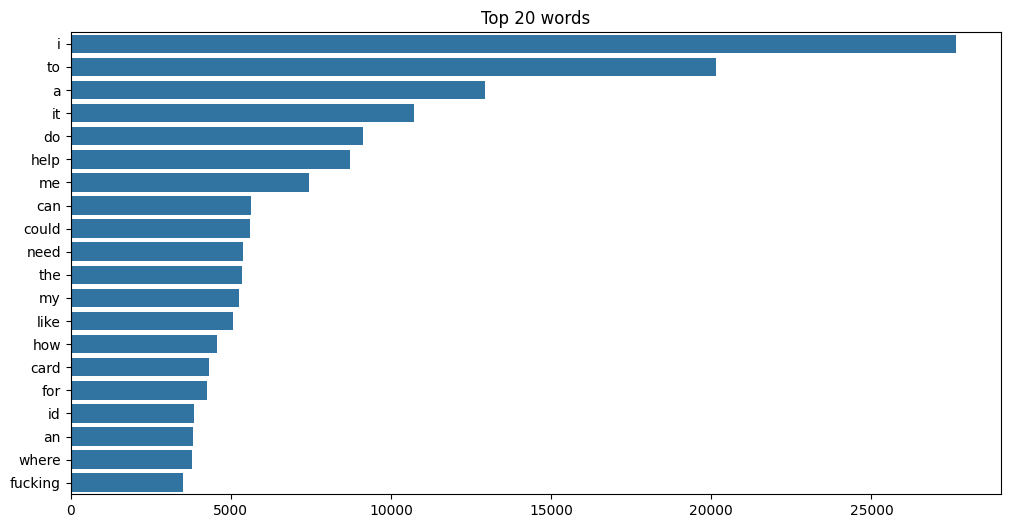

In [10]:
top_words = dict(word_counts.most_common(20))

plt.figure(figsize=(12,6))
sns.barplot(x=list(top_words.values()), y=list(top_words.keys()))
plt.title("Top 20 words")
plt.show()

It may be a bit of a stretch but looking at the 20th most frequent word, the chatbot may not be perfect.

Let's see how if the type of intent affects it length in tokens.

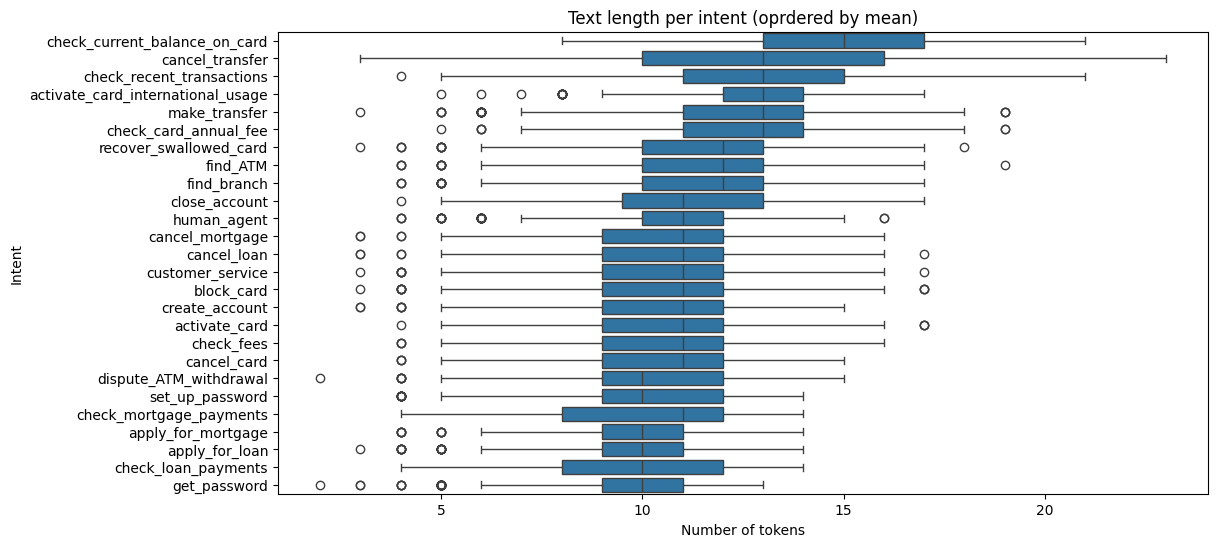

In [11]:
intent_order = df.groupby("intent")["text_length"].mean().sort_values(ascending=False).index

plt.figure(figsize=(12,6))
sns.boxplot(data=df, x="text_length", y="intent", order=intent_order)
plt.title("Text length per intent (oprdered by mean)")
plt.xlabel("Number of tokens")
plt.ylabel("Intent")
plt.show()

As a sanity check, I like to run a term frequency-inverse document frequency (TF-IDF) heatmap of the most common words among the intents.
It shows relative 'importance' of the terms across the dataset.
I used standard stopword removal for English here to remove function words like I, the, and, etc.
This is one way of seeing if the intents are correctly classified.

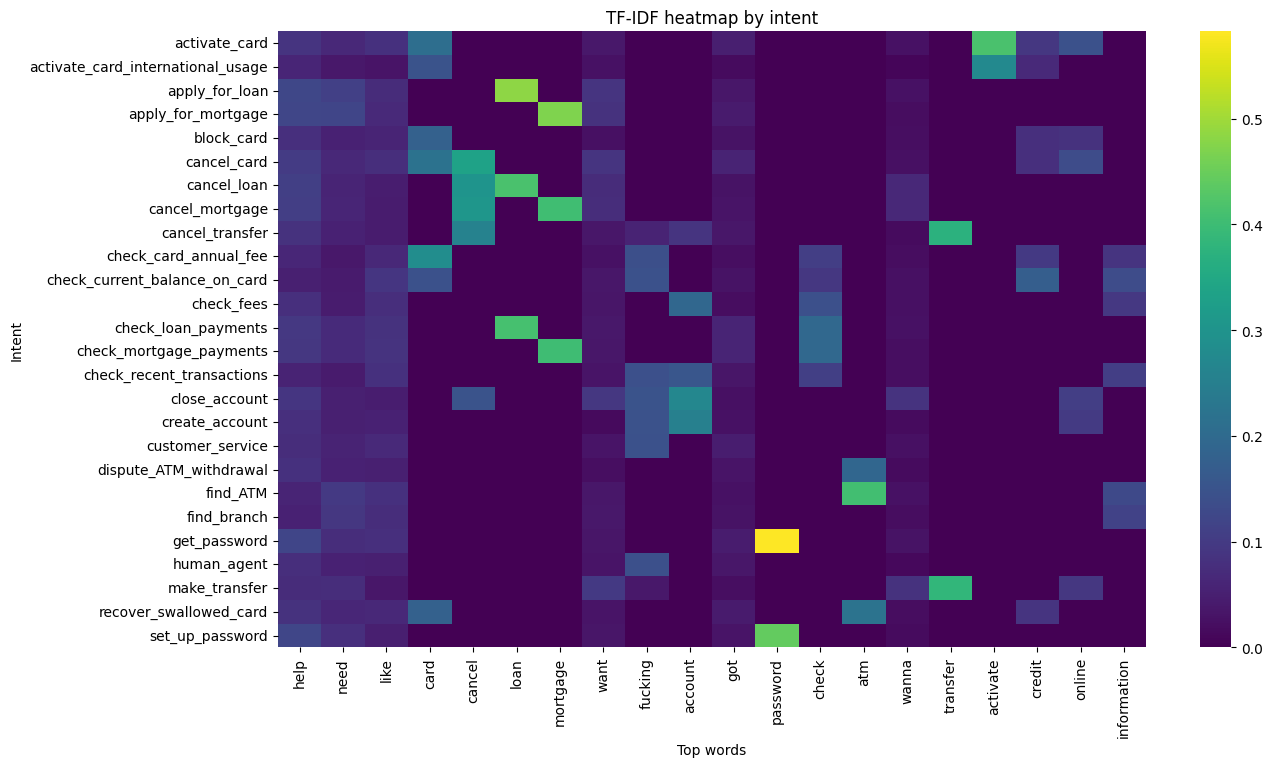

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=1000,
    stop_words="english"
)

X = vectorizer.fit_transform(df["instruction"])


# get feature names
feature_names = vectorizer.get_feature_names_out()

# Sparse Matrix -> DataFrame
tfidf_full = pd.DataFrame(X.toarray(), columns=feature_names)
tfidf_full["intent"] = df["intent"].values

# mean per intent
intent_tfidf = tfidf_full.groupby("intent").mean()

# global top 20 words by mean TF-IDF
tfidf_means = np.asarray(X.mean(axis=0)).flatten()

tfidf_summary = pd.DataFrame({
    "word": feature_names,
    "mean_tfidf": tfidf_means
})

top_features = (
    tfidf_summary
    .sort_values("mean_tfidf", ascending=False)
    .head(20)["word"]
)

# create heatmap
plt.figure(figsize=(14,8))
sns.heatmap(intent_tfidf[top_features], cmap="viridis")
plt.title("TF-IDF heatmap by intent")
plt.xlabel("Top words")
plt.ylabel("Intent")
plt.show()

And we can see that e.g. "password" comes up most frequently in get_password and set_up_password.
"loan" is most frequent in apply_for_loan, cancel_loan, check_loan_payments.
There are several more interesting things here, such as "cancel", "check", or "atm".
I also think it's worth mentioning that for "help", "need", and "like", no intent stands out, as these words are distributed pretty evenly.

To check differences across intents, it may also be a good idea to use a clustering method, such as PCA or t-SNE, and have a look which intents are closer/more distant to each other

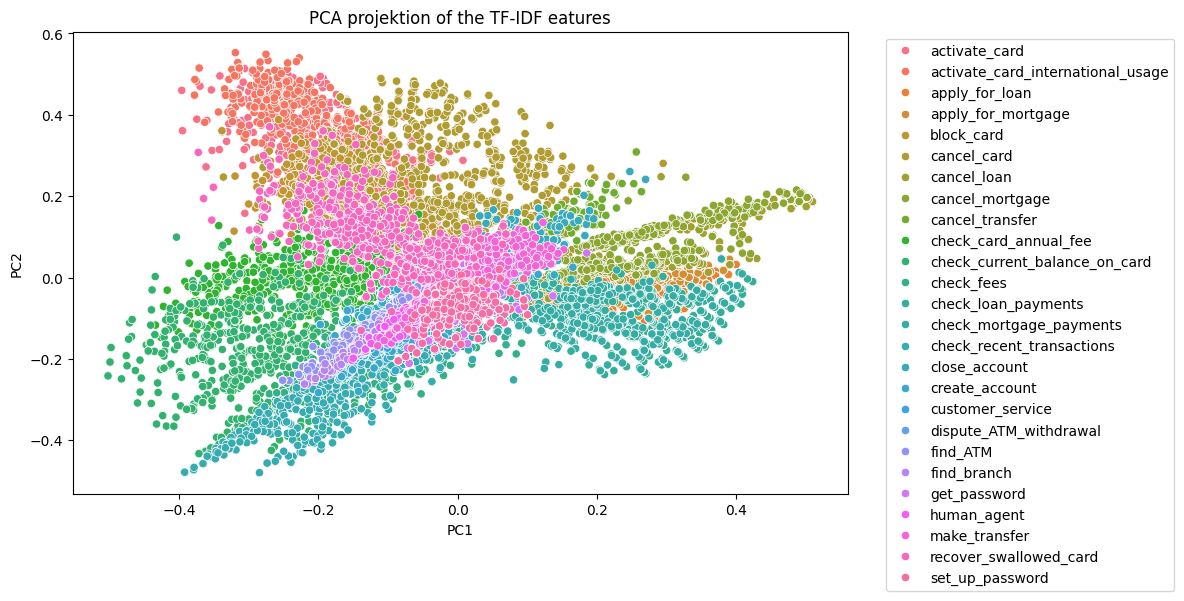

In [13]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X.toarray())

plt.figure(figsize=(10,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=df["intent"], legend=True)
plt.title("PCA projektion of the TF-IDF eatures")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left")
plt.show()

## ML section
Next, we can oreoare the data set, analyze intentws, do a train/test split, and train a BERT intent classifier on it.
Unless already installed, you may have to use
> pip install datasets transformers torch scikit-learn evaluate

We start the preparation by assigning 20% to the train part and 80% to the test set.


In [14]:
from datasets import load_dataset

# Load dataset from HuggingFace; it's commented out, but you can activate it if you skipped the EDA partpart
#dataset = load_dataset("bitext/Bitext-retail-banking-llm-chatbot-training-dataset")

# Convert to train/test split (20/80)
dataset = dataset["train"].train_test_split(test_size=0.2, seed=42)

train_dataset = dataset["train"]
test_dataset = dataset["test"]

print(train_dataset[0])
print(train_dataset[1])

{'tags': 'BLM', 'instruction': 'help me seeing the loan payments', 'category': 'LOAN', 'intent': 'check_loan_payments', 'response': 'I\'m here to assist you with checking your loan payments. To view your loan payments, please follow these simple steps:\n\n1. Log in to your account on our website.\n2. Navigate to the "Loan" or "Loan Payments" section.\n3. You should be able to see a list of your loan payments, including the dates and amounts.\n\nIf you\'re having trouble finding the section or accessing your loan payment information, please let me know. I\'ll be glad to provide further guidance.'}
{'tags': 'BCEIZ', 'instruction': 'I am looking for a olan, can you help me?', 'category': 'LOAN', 'intent': 'apply_for_loan', 'response': "I'm here to assist you in finding the right loan for your needs. To get started, I'll need a bit more information. Could you please let me know the purpose of the loan and the approximate amount you're looking to borrow? This will help me provide you with t

Next, the labels must be encoded numerically for BERT.
We can use a quick function for it.
And some print() at the end for sanity checks.

In [15]:
# Extract unique intent labels
label_list = list(set(train_dataset["intent"]))

# Create mappings
label2id = {label: i for i, label in enumerate(label_list)}
id2label = {i: label for label, i in label2id.items()}

# Function to convert text label to numeric label
def encode_labels(example):
    example["label"] = label2id[example["intent"]]
    return example

# Apply encoding
train_dataset = train_dataset.map(encode_labels)
test_dataset = test_dataset.map(encode_labels)

print("Number of labels:", len(label_list))
print(train_dataset[0])

Map:   0%|          | 0/20436 [00:00<?, ? examples/s]

Map:   0%|          | 0/5109 [00:00<?, ? examples/s]

Number of labels: 26
{'tags': 'BLM', 'instruction': 'help me seeing the loan payments', 'category': 'LOAN', 'intent': 'check_loan_payments', 'response': 'I\'m here to assist you with checking your loan payments. To view your loan payments, please follow these simple steps:\n\n1. Log in to your account on our website.\n2. Navigate to the "Loan" or "Loan Payments" section.\n3. You should be able to see a list of your loan payments, including the dates and amounts.\n\nIf you\'re having trouble finding the section or accessing your loan payment information, please let me know. I\'ll be glad to provide further guidance.', 'label': 3}


Based on the EDA above, we already know that most texts are very short.
The longest intent was 23 tokens.
Therefore, we can safely use max_length of 64, rather than 128.


In [16]:
import importlib.util
import subprocess
import sys

!{sys.executable} -m pip install "accelerate>=0.26.0"

packages = {
    "torch": "torch",
    "transformers": "transformers",
    "datasets": "datasets",
    "evaluate": "evaluate",
    "sklearn": "scikit-learn",
    "seaborn": "seaborn",
    "matplotlib": "matplotlib"
}

for module_name, pip_name in packages.items():
    if importlib.util.find_spec(module_name) is None:
        print(f"{module_name} not found. Installing {pip_name}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pip_name])
    else:
        print(f"{module_name} already installed ✅")

torch already installed ✅
transformers already installed ✅
datasets already installed ✅
evaluate not found. Installing evaluate...
sklearn already installed ✅
seaborn already installed ✅
matplotlib already installed ✅


In [17]:
from transformers import AutoTokenizer

# Load pretrained tokenizer
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
#tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# Tokenization function
def tokenize_function(example):
    return tokenizer(
        example["instruction"],
        padding="max_length",
        truncation=True,
        max_length=64
    )

# Apply tokenizer
train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

# Set format for PyTorch
train_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"]
)

test_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"]
)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/20436 [00:00<?, ? examples/s]

Map:   0%|          | 0/5109 [00:00<?, ? examples/s]

Now let's load the BERT model. I initially chose the pretty standard "bert-base-uncased" here but then realized how long it takes on my CPU so I changed to "distilbert-base-uncased". It should not affect performance too much but reduce training time significantly.

In [18]:
from transformers import AutoModelForSequenceClassification

# Load pretrained BERT model for classification
model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=len(label_list),
    id2label=id2label,
    label2id=label2id
)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [19]:
from transformers import TrainingArguments, Trainer
import evaluate
import numpy as np

# Load accuracy metric
accuracy = evaluate.load("accuracy")

# Define metric computation
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)
    return accuracy.compute(predictions=predictions, references=labels)

# Define training arguments
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    num_train_epochs=2, #here I initially had 3, but changed to 2 to make it run faster
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    logging_dir="./logs",
    load_best_model_at_end=True
)

# Create trainer object
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Now we can first train/fine-tune and then evaluate the model.

In [21]:
# Start training
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.022608,0.011505,0.998238
2,0.003076,0.003658,0.999217


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=2556, training_loss=0.13239679168705742, metrics={'train_runtime': 585.1591, 'train_samples_per_second': 69.848, 'train_steps_per_second': 4.368, 'total_flos': 1344524045948928.0, 'train_loss': 0.13239679168705742, 'epoch': 2.0})

In [22]:
# Evaluate model on test set
results = trainer.evaluate()
print(results)

{'eval_loss': 0.0036578220315277576, 'eval_accuracy': 0.999217067919358, 'eval_runtime': 18.2655, 'eval_samples_per_second': 279.707, 'eval_steps_per_second': 17.519, 'epoch': 2.0}


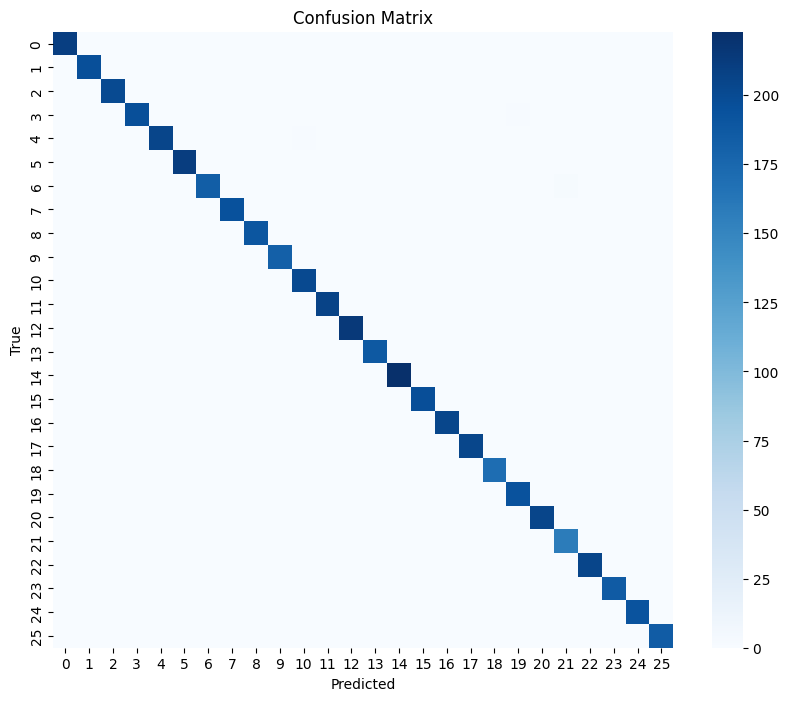

In [23]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Get predictions
predictions = trainer.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [24]:
from collections import Counter
print(Counter(df["intent"]))

Counter({'activate_card': 1000, 'find_branch': 1000, 'check_recent_transactions': 999, 'close_account': 999, 'human_agent': 999, 'block_card': 998, 'customer_service': 998, 'find_ATM': 998, 'activate_card_international_usage': 997, 'apply_for_mortgage': 997, 'make_transfer': 997, 'cancel_card': 996, 'cancel_mortgage': 996, 'check_card_annual_fee': 996, 'create_account': 996, 'cancel_transfer': 995, 'recover_swallowed_card': 994, 'check_current_balance_on_card': 993, 'apply_for_loan': 992, 'cancel_loan': 990, 'check_mortgage_payments': 990, 'check_loan_payments': 989, 'dispute_ATM_withdrawal': 989, 'check_fees': 947, 'set_up_password': 901, 'get_password': 799})


The confusion matrix now shows which intent classes are often confused.